In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets from local paths
chennai = pd.read_csv(r'C:\maps\datasets\chennai_ndvi_2004_2024.csv')
shanghai = pd.read_csv(r'C:\maps\datasets\ndvi_shanghai_2004_2024.csv')

# Add city labels
chennai['City'] = 'Chennai'
shanghai['City'] = 'Shanghai'

# Combine datasets
df = pd.concat([chennai, shanghai], ignore_index=True)

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])  # Change 'Date' if your actual column name is different
df['Year'] = df['Date'].dt.year

# Rename NDVI column if it's not already named 'NDVI'
if 'NDVI' not in df.columns:
    ndvi_col = [col for col in df.columns if 'ndvi' in col.lower()][0]
    df.rename(columns={ndvi_col: 'NDVI'}, inplace=True)

# Assign 5-year periods
def assign_period(year):
    if 2005 <= year <= 2009:
        return '2005–2009'
    elif 2010 <= year <= 2014:
        return '2010–2014'
    elif 2015 <= year <= 2019:
        return '2015–2019'
    elif 2020 <= year <= 2024:
        return '2020–2024'
    else:
        return 'Out of Range'

df['Period'] = df['Year'].apply(assign_period)

# --- 1. Bar Chart: Average NDVI per 5-Year Interval ---
bar_data = df[df['Period'] != 'Out of Range'].groupby(['Period', 'City'])['NDVI'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=bar_data, x='Period', y='NDVI', hue='City')
plt.title('Average NDVI per 5-Year Interval')
plt.ylabel('Average NDVI')
plt.xlabel('Time Period')
plt.legend(title='City')
plt.tight_layout()
plt.show()

# --- 2. Line Graph: NDVI Over Time (2005–2024) ---
line_data = df[(df['Year'] >= 2005) & (df['Year'] <= 2024)]

plt.figure(figsize=(12,6))
sns.lineplot(data=line_data, x='Date', y='NDVI', hue='City')
plt.title('NDVI Over Time (2005–2024)')
plt.ylabel('NDVI')
plt.xlabel('Date')
plt.legend(title='City')
plt.tight_layout()
plt.show()

# --- 3. Box Plot: NDVI Distribution for Each City ---
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='City', y='NDVI')
plt.title('NDVI Distribution for Each City')
plt.ylabel('NDVI')
plt.xlabel('City')
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'seaborn'

In [2]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets from local paths
chennai = pd.read_csv(r'C:\maps\datasets\chennai_ndvi_2004_2024.csv')
shanghai = pd.read_csv(r'C:\maps\datasets\ndvi_shanghai_2004_2024.csv')

# Add city labels
chennai['City'] = 'Chennai'
shanghai['City'] = 'Shanghai'

# Combine datasets
df = pd.concat([chennai, shanghai], ignore_index=True)

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])  # Change 'Date' if your actual column name is different
df['Year'] = df['Date'].dt.year

# Rename NDVI column if it's not already named 'NDVI'
if 'NDVI' not in df.columns:
    ndvi_col = [col for col in df.columns if 'ndvi' in col.lower()][0]
    df.rename(columns={ndvi_col: 'NDVI'}, inplace=True)

# Assign 5-year periods
def assign_period(year):
    if 2005 <= year <= 2009:
        return '2005–2009'
    elif 2010 <= year <= 2014:
        return '2010–2014'
    elif 2015 <= year <= 2019:
        return '2015–2019'
    elif 2020 <= year <= 2024:
        return '2020–2024'
    else:
        return 'Out of Range'

df['Period'] = df['Year'].apply(assign_period)

# --- 1. Bar Chart: Average NDVI per 5-Year Interval ---
bar_data = df[df['Period'] != 'Out of Range'].groupby(['Period', 'City'])['NDVI'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=bar_data, x='Period', y='NDVI', hue='City')
plt.title('Average NDVI per 5-Year Interval')
plt.ylabel('Average NDVI')
plt.xlabel('Time Period')
plt.legend(title='City')
plt.tight_layout()
plt.show()

# --- 2. Line Graph: NDVI Over Time (2005–2024) ---
line_data = df[(df['Year'] >= 2005) & (df['Year'] <= 2024)]

plt.figure(figsize=(12,6))
sns.lineplot(data=line_data, x='Date', y='NDVI', hue='City')
plt.title('NDVI Over Time (2005–2024)')
plt.ylabel('NDVI')
plt.xlabel('Date')
plt.legend(title='City')
plt.tight_layout()
plt.show()

# --- 3. Box Plot: NDVI Distribution for Each City ---
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='City', y='NDVI')
plt.title('NDVI Distribution for Each City')
plt.ylabel('NDVI')
plt.xlabel('City')
plt.tight_layout()
plt.show()

KeyError: 'Date'

In [4]:
print(chennai.columns)
print(shanghai.columns)


Index(['date', 'NDVI', 'City'], dtype='object')
Index(['Year', 'NDVI', 'City'], dtype='object')


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
chennai = pd.read_csv(r'C:\maps\datasets\chennai_ndvi_2004_2024.csv')
shanghai = pd.read_csv(r'C:\maps\datasets\ndvi_shanghai_2004_2024.csv')

# Convert Chennai's 'date' column to datetime
chennai['date'] = pd.to_datetime(chennai['date'])
chennai['Year'] = chennai['date'].dt.year
chennai.rename(columns={'date': 'Date'}, inplace=True)

# For Shanghai, create a fake 'Date' column using January 1st of each year
shanghai['Date'] = pd.to_datetime(shanghai['Year'].astype(str) + '-01-01')

# Combine both datasets
df = pd.concat([chennai, shanghai], ignore_index=True)

# Assign 5-year periods
def assign_period(year):
    if 2005 <= year <= 2009:
        return '2005–2009'
    elif 2010 <= year <= 2014:
        return '2010–2014'
    elif 2015 <= year <= 2019:
        return '2015–2019'
    elif 2020 <= year <= 2024:
        return '2020–2024'
    else:
        return 'Out of Range'

df['Period'] = df['Year'].apply(assign_period)

# --- 1. Bar Chart: Average NDVI per 5-Year Interval ---
bar_data = df[df['Period'] != 'Out of Range'].groupby(['Period', 'City'])['NDVI'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=bar_data, x='Period', y='NDVI', hue='City')
plt.title('Average NDVI per 5-Year Interval')
plt.ylabel('Average NDVI')
plt.xlabel('Time Period')
plt.legend(title='City')
plt.tight_layout()
plt.show()

# --- 2. Line Graph: NDVI Over Time (2005–2024) ---
line_data = df[(df['Year'] >= 2005) & (df['Year'] <= 2024)]

plt.figure(figsize=(12,6))
sns.lineplot(data=line_data, x='Date', y='NDVI', hue='City')
plt.title('NDVI Over Time (2005–2024)')
plt.ylabel('NDVI')
plt.xlabel('Date')
plt.legend(title='City')
plt.tight_layout()
plt.show()

# --- 3. Box Plot: NDVI Distribution for Each City ---
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='City', y='NDVI')
plt.title('NDVI Distribution for Each City')
plt.ylabel('NDVI')
plt.xlabel('City')
plt.tight_layout()
plt.show()


KeyError: 'City'

In [6]:


import ee
import pandas as pd

# Authenticate & initialize
ee.Authenticate()   # Follow the link, log in, paste the token
ee.Initialize()

# STEP 2: Define Chennai region and NDVI dataset (MODIS)
chennai = ee.Geometry.Point([80.2707, 13.0827]).buffer(30000)

ndvi_collection = ee.ImageCollection('MODIS/006/MOD13Q1') \
    .filterBounds(chennai) \
    .filterDate('2004-01-01', '2024-12-31') \
    .select('NDVI') \
    .map(lambda img: img.multiply(0.0001).copyProperties(img, ['system:time_start']))

# STEP 3: Compute yearly NDVI
def get_yearly_ndvi(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')
    mean_ndvi = ndvi_collection.filterDate(start, end).mean()
    stats = mean_ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=chennai,
        scale=250,
        maxPixels=1e9
    )
    return ee.Feature(None, {'year': year, 'NDVI': stats.get('NDVI')})

years = ee.List.sequence(2004, 2024)
features = years.map(lambda y: get_yearly_ndvi(ee.Number(y)))
ndvi_fc = ee.FeatureCollection(features)

# STEP 4: Convert result to pandas DataFrame and save
data = ndvi_fc.getInfo()
records = [{'Year': f['properties']['year'], 'NDVI': f['properties']['NDVI']} for f in data['features']]
df = pd.DataFrame(records)

# Save to CSV
df.to_csv('chennai_yearly_ndvi_2004_2024.csv', index=False)

# Show the result
print(df)


C:\Users\irctc\AppData\Roaming\Python\Python312\site-packages\ee\deprecation.py:207: DeprecationWarning: 

Attention required for MODIS/006/MOD13Q1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/MODIS_006_MOD13Q1

  warnings.warn(warning, category=DeprecationWarning)


EEException: Dictionary.get: Dictionary does not contain key: 'NDVI'.

In [7]:
# Step 1: Install and authenticate Earth Engine
!pip install earthengine-api --quiet

import ee
import pandas as pd

# Authenticate & initialize
ee.Authenticate()
ee.Initialize()

# Step 2: Define Chennai region and load NDVI collection
chennai = ee.Geometry.Point([80.2707, 13.0827]).buffer(30000)

ndvi_collection = ee.ImageCollection('MODIS/006/MOD13Q1') \
    .filterBounds(chennai) \
    .filterDate('2004-01-01', '2025-12-31') \
    .select('NDVI') \
    .map(lambda img: img.multiply(0.0001).copyProperties(img, ['system:time_start']))

# Step 3: Define function to safely compute mean NDVI per year
def get_yearly_ndvi(year):
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')
    mean_image = ndvi_collection.filterDate(start, end).mean()
    stats = mean_image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=chennai,
        scale=250,
        maxPixels=1e9
    )
    # If NDVI is not present, set as null
    ndvi_value = stats.get('NDVI')
    return ee.Feature(None, {'year': year, 'NDVI': ndvi_value})

# Step 4: Apply across all years
years = ee.List.sequence(2004, 2025)
features = years.map(lambda y: get_yearly_ndvi(ee.Number(y)))
ndvi_fc = ee.FeatureCollection(features)

# Step 5: Convert to pandas DataFrame
data = ndvi_fc.getInfo()
records = []

for f in data['features']:
    year = f['properties']['year']
    ndvi = f['properties'].get('NDVI', None)
    records.append({'Year': year, 'NDVI': ndvi})

df = pd.DataFrame(records)

# Save to CSV
df.to_csv('chennai_yearly_ndvi_2004_2025.csv', index=False)

# Display the result
print(df)


EEException: Dictionary.get: Dictionary does not contain key: 'NDVI'.

In [8]:
import ee
import pandas as pd

# Authenticate and initialize
ee.Authenticate()
ee.Initialize()

# Define Chennai region
chennai = ee.Geometry.Point([80.2707, 13.0827]).buffer(30000)

# Load MODIS NDVI and scale to correct range
ndvi_collection = ee.ImageCollection('MODIS/006/MOD13Q1') \
    .filterBounds(chennai) \
    .filterDate('2004-01-01', '2025-12-31') \
    .select('NDVI') \
    .map(lambda img: img.multiply(0.0001).copyProperties(img, ['system:time_start']))

# Safely compute NDVI year by year
years = list(range(2004, 2026))
ndvi_list = []

for year in years:
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, 'year')
    try:
        mean_img = ndvi_collection.filterDate(start, end).mean()
        ndvi_dict = mean_img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=chennai,
            scale=250,
            maxPixels=1e9
        ).getInfo()
        ndvi_value = ndvi_dict.get('NDVI', None)
    except Exception as e:
        ndvi_value = None
        print(f"Failed to fetch NDVI for {year}: {e}")
    
    ndvi_list.append({'Year': year, 'NDVI': ndvi_value})

# Convert to DataFrame and save
df = pd.DataFrame(ndvi_list)
df.to_csv('chennai_yearly_ndvi_2004_2025.csv', index=False)
print(df)


    Year      NDVI
0   2004  0.388031
1   2005  0.377792
2   2006  0.386297
3   2007  0.402115
4   2008  0.408193
5   2009  0.360696
6   2010  0.416577
7   2011  0.412539
8   2012  0.393648
9   2013  0.416299
10  2014  0.387675
11  2015  0.400047
12  2016  0.405528
13  2017  0.387759
14  2018  0.402405
15  2019  0.382414
16  2020  0.428881
17  2021  0.432780
18  2022  0.424338
19  2023  0.427080
20  2024       NaN
21  2025       NaN


In [9]:
# Convert to DataFrame and save
df = pd.DataFrame(ndvi_list)

# Save to your custom path
df.to_csv(r'C:\maps\datasets\chennai_yearly_ndvi_2004_2025.csv', index=False)

# Print confirmation and preview
print("CSV saved to C:\\maps\\datasets\\chennai_yearly_ndvi_2004_2025.csv")
print(df)


CSV saved to C:\maps\datasets\chennai_yearly_ndvi_2004_2025.csv
    Year      NDVI
0   2004  0.388031
1   2005  0.377792
2   2006  0.386297
3   2007  0.402115
4   2008  0.408193
5   2009  0.360696
6   2010  0.416577
7   2011  0.412539
8   2012  0.393648
9   2013  0.416299
10  2014  0.387675
11  2015  0.400047
12  2016  0.405528
13  2017  0.387759
14  2018  0.402405
15  2019  0.382414
16  2020  0.428881
17  2021  0.432780
18  2022  0.424338
19  2023  0.427080
20  2024       NaN
21  2025       NaN


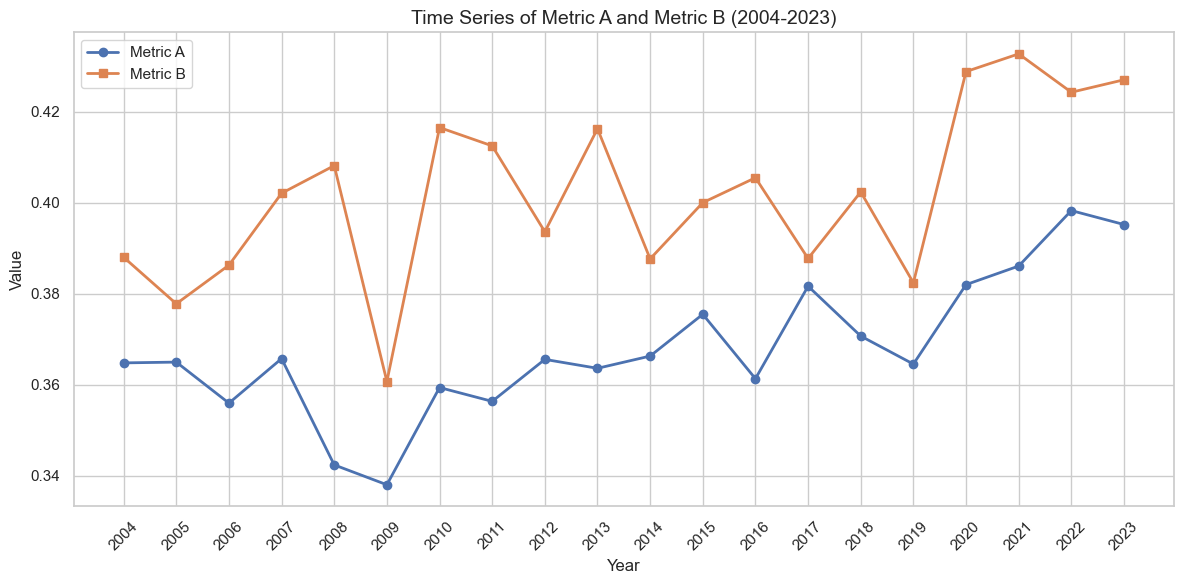

<Figure size 1200x600 with 0 Axes>

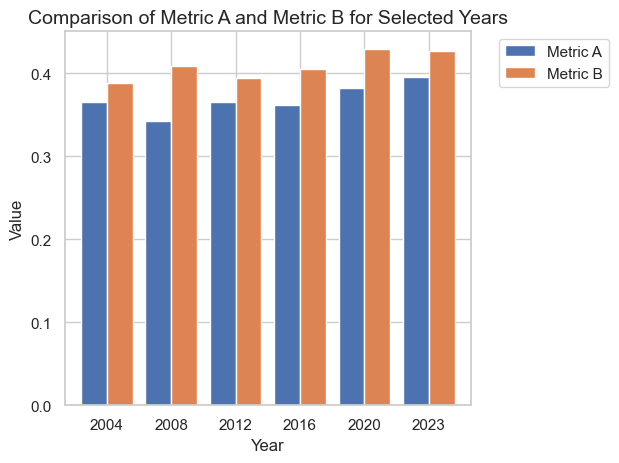

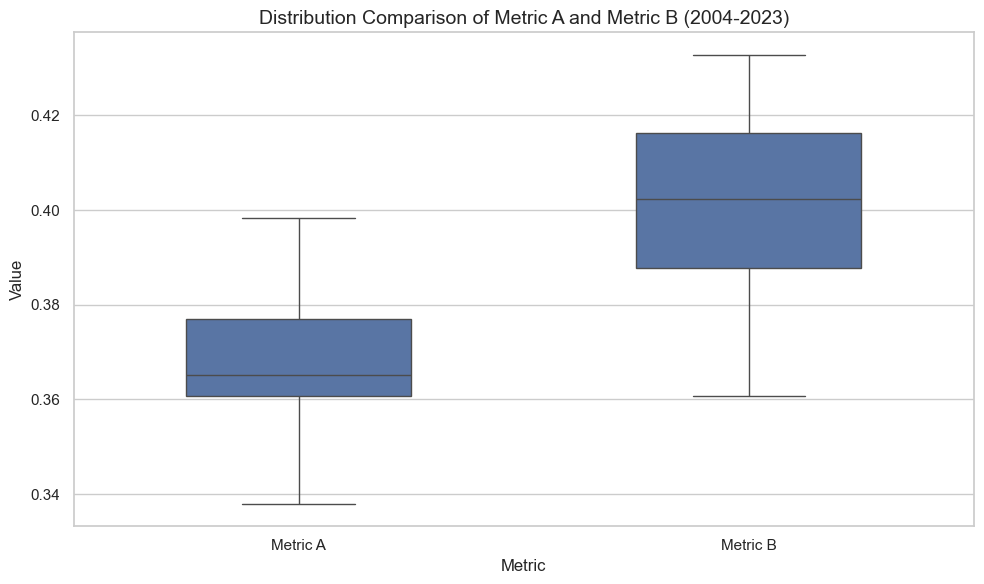

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrames from the provided data
data_a = {
    'Year': [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 
             2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'Metric A': [0.364792, 0.364963, 0.355937, 0.365731, 0.342346, 0.337976, 
                 0.359369, 0.356327, 0.365562, 0.3636, 0.366291, 0.375486, 
                 0.361312, 0.381663, 0.370693, 0.364526, 0.382009, 0.386099, 
                 0.398304, 0.395234]
}

data_b = {
    'Year': [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 
             2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'Metric B': [0.388031, 0.377792, 0.386297, 0.402115, 0.408193, 0.360696, 
                 0.416577, 0.412539, 0.393648, 0.416299, 0.387675, 0.400047, 
                 0.405528, 0.387759, 0.402405, 0.382414, 0.428881, 0.43278, 
                 0.424338, 0.42708]
}

df_a = pd.DataFrame(data_a)
df_b = pd.DataFrame(data_b)

# Merge the two DataFrames
df = pd.merge(df_a, df_b, on='Year')

# Set Year as index for time series plotting
df.set_index('Year', inplace=True)

# Set modern style (updated from plt.style.use('seaborn'))
sns.set_theme(style="whitegrid")  # Uses Seaborn's modern theme
plt.rcParams['figure.facecolor'] = 'white'  # Sets white background

# 1. Time Series Line Chart
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Metric A'], marker='o', label='Metric A', linewidth=2)
plt.plot(df.index, df['Metric B'], marker='s', label='Metric B', linewidth=2)
plt.title('Time Series of Metric A and Metric B (2004-2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Bar Graph (Comparing Metrics for Selected Years)
plt.figure(figsize=(12, 6))
df_sample = df.loc[[2004, 2008, 2012, 2016, 2020, 2023]]  # Sample years
df_sample.plot(kind='bar', width=0.8)
plt.title('Comparison of Metric A and Metric B for Selected Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Boxplot (Distribution Comparison)
plt.figure(figsize=(10, 6))
df_melted = df.reset_index().melt(id_vars='Year', value_vars=['Metric A', 'Metric B'], 
                                var_name='Metric', value_name='Value')
sns.boxplot(x='Metric', y='Value', data=df_melted, width=0.5)
plt.title('Distribution Comparison of Metric A and Metric B (2004-2023)', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.tight_layout()
plt.show()

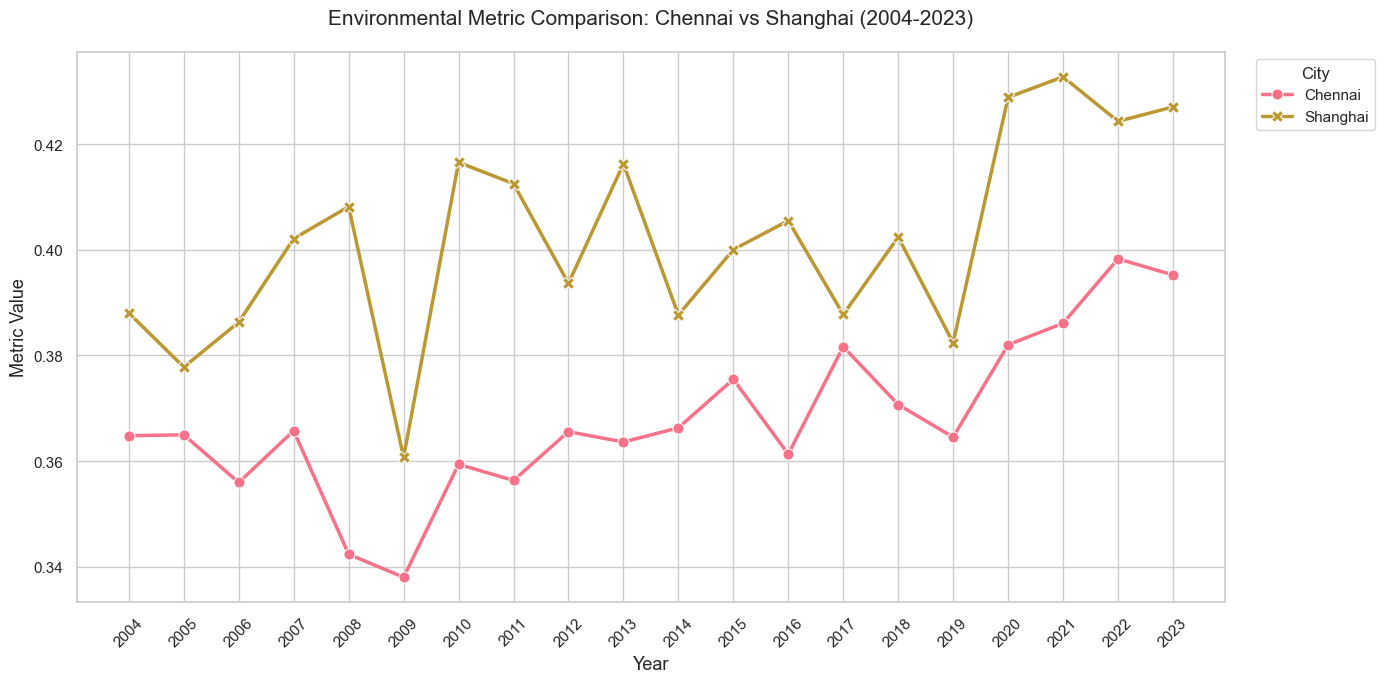

<Figure size 1400x700 with 0 Axes>

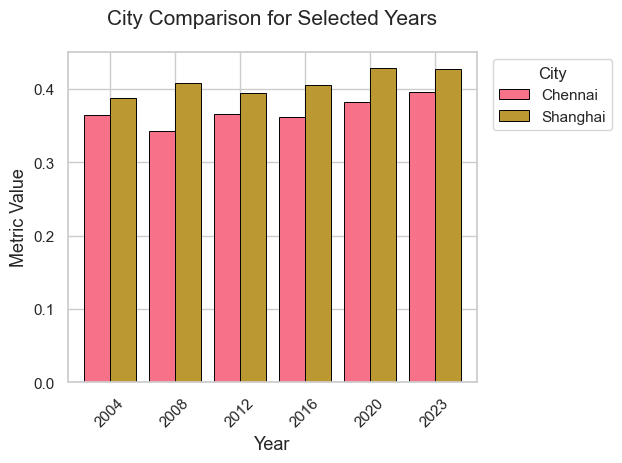

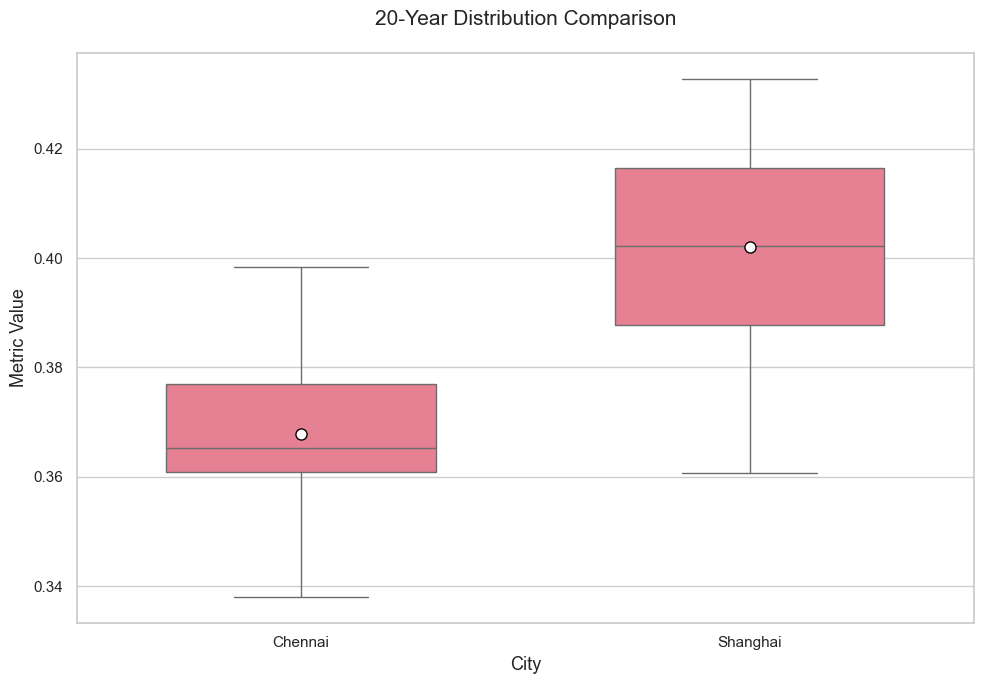

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrames from the provided data
data = {
    'Year': [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 
             2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'Chennai': [0.364792, 0.364963, 0.355937, 0.365731, 0.342346, 0.337976, 
                0.359369, 0.356327, 0.365562, 0.3636, 0.366291, 0.375486, 
                0.361312, 0.381663, 0.370693, 0.364526, 0.382009, 0.386099, 
                0.398304, 0.395234],
    'Shanghai': [0.388031, 0.377792, 0.386297, 0.402115, 0.408193, 0.360696, 
                 0.416577, 0.412539, 0.393648, 0.416299, 0.387675, 0.400047, 
                 0.405528, 0.387759, 0.402405, 0.382414, 0.428881, 0.43278, 
                 0.424338, 0.42708]
}

df = pd.DataFrame(data).set_index('Year')

# Set modern style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True

# 1. Time Series Line Chart
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, markers=True, dashes=False, linewidth=2.5, 
             markersize=8, marker='o')
plt.title('Environmental Metric Comparison: Chennai vs Shanghai (2004-2023)', 
          fontsize=15, pad=20)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Metric Value', fontsize=13)
plt.xticks(df.index, rotation=45)
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Bar Graph (Comparison for Key Years)
key_years = [2004, 2008, 2012, 2016, 2020, 2023]
plt.figure(figsize=(14, 7))
df.loc[key_years].plot(kind='bar', width=0.8, edgecolor='black', linewidth=0.7)
plt.title('City Comparison for Selected Years', fontsize=15, pad=20)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Metric Value', fontsize=13)
plt.xticks(rotation=45)
plt.legend(title='City', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. Boxplot (Distribution Comparison)
plt.figure(figsize=(10, 7))
df_melted = df.reset_index().melt(id_vars='Year', 
                                 value_vars=['Chennai', 'Shanghai'],
                                 var_name='City', 
                                 value_name='Metric Value')
sns.boxplot(x='City', y='Metric Value', data=df_melted, width=0.6,
            showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", 
                      "markeredgecolor":"black", "markersize":"8"})
plt.title('20-Year Distribution Comparison', fontsize=15, pad=20)
plt.xlabel('City', fontsize=13)
plt.ylabel('Metric Value', fontsize=13)
plt.tight_layout()
plt.show()

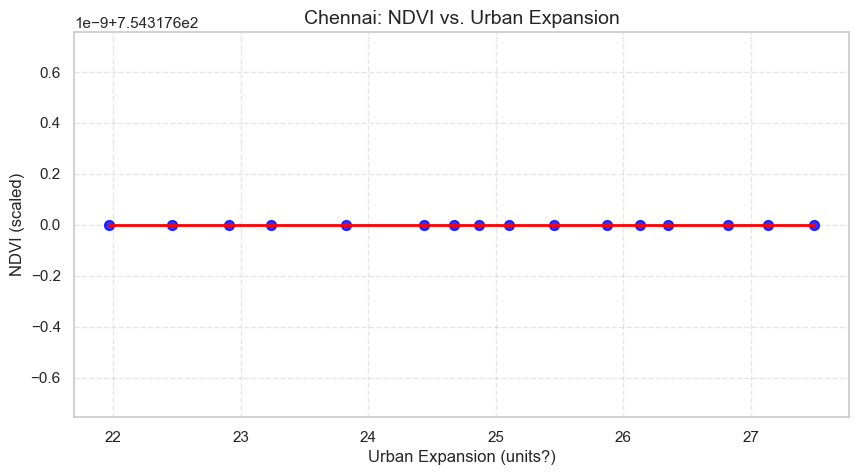

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chennai Data
chennai_ndvi = [754.3176] * 16  # Matching length of urban data
chennai_urban = [21.97004, 22.45966, 22.91177, 23.23889, 23.82691, 
                 24.4366, 24.67205, 24.87224, 25.1037, 25.45343, 
                 25.87244, 26.1336, 26.35337, 26.81817, 27.13624, 27.49237]

df_chennai = pd.DataFrame({
    'NDVI': chennai_ndvi,
    'Urban_Expansion': chennai_urban
})

# Plot Chennai
plt.figure(figsize=(10, 5))
sns.regplot(x='Urban_Expansion', y='NDVI', data=df_chennai,
            scatter_kws={'color': 'blue', 's': 50}, 
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Chennai: NDVI vs. Urban Expansion', fontsize=14)
plt.xlabel('Urban Expansion (units?)', fontsize=12)
plt.ylabel('NDVI (scaled)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

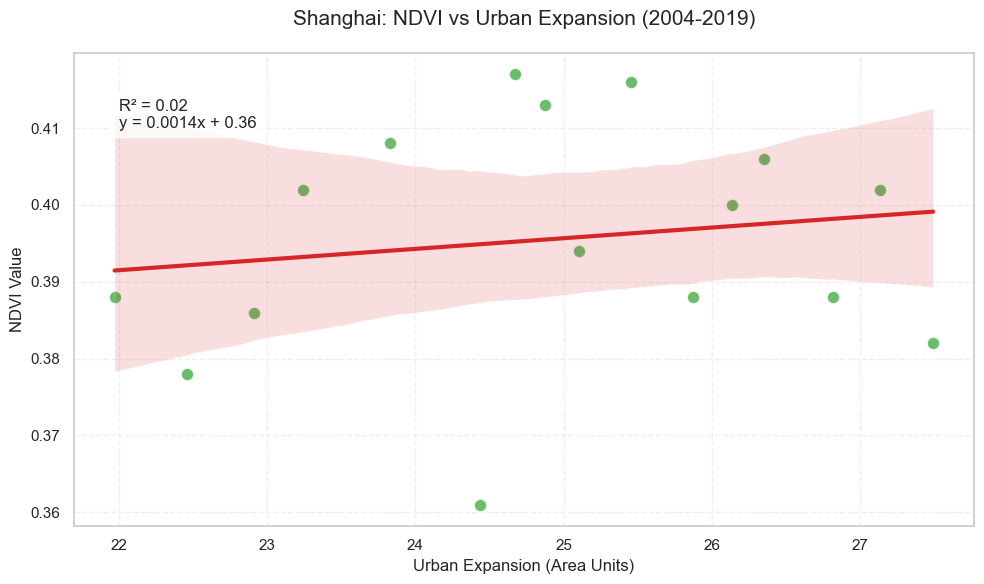

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Shanghai Data
shanghai_urban = [21.97004, 22.45966, 22.91177, 23.23889, 23.82691,
                  24.4366, 24.67205, 24.87224, 25.1037, 25.45343,
                  25.87244, 26.1336, 26.35337, 26.81817, 27.13624, 27.49237]

shanghai_ndvi = [0.388, 0.378, 0.386, 0.402, 0.408, 0.361, 0.417, 0.413,
                 0.394, 0.416, 0.388, 0.400, 0.406, 0.388, 0.402, 0.382]

# Create DataFrame
df_shanghai = pd.DataFrame({
    'NDVI': shanghai_ndvi,
    'Urban_Expansion': shanghai_urban
})

# Plot
plt.figure(figsize=(10, 6))
sns.regplot(x='Urban_Expansion', y='NDVI', data=df_shanghai,
            scatter_kws={'color': '#2ca02c', 's': 80, 'alpha': 0.7, 'edgecolor': 'w'},
            line_kws={'color': '#d62728', 'linewidth': 3})

plt.title('Shanghai: NDVI vs Urban Expansion (2004-2019)', fontsize=15, pad=20)
plt.xlabel('Urban Expansion (Area Units)', fontsize=12)
plt.ylabel('NDVI Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Annotate stats
slope, intercept, r_value, p_value, std_err = linregress(df_shanghai['Urban_Expansion'], df_shanghai['NDVI'])
plt.text(22, 0.41, f'R² = {r_value**2:.2f}\ny = {slope:.4f}x + {intercept:.2f}',
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

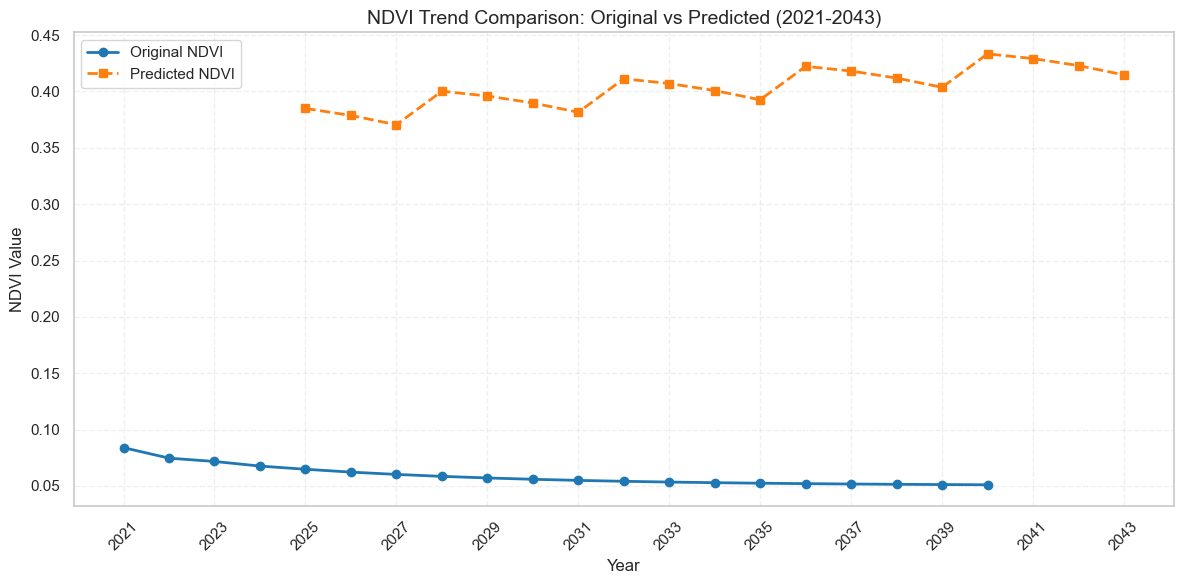

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your original data
original_data = {
    'Year': list(range(2021, 2041)),
    'NDVI': [0.084018, 0.074696, 0.071754, 0.067674, 0.064847,
             0.062309, 0.060267, 0.05855, 0.057132, 0.055952,
             0.054974, 0.054161, 0.053487, 0.052927, 0.052462,
             0.052077, 0.051756, 0.05149, 0.051269, 0.051086]
}

# Your predicted data
predicted_data = {
    'Year': list(range(2025, 2044)),
    'Predicted_NDVI': [0.384929, 0.378718, 0.370486, 0.40016, 0.395985,
                       0.389774, 0.381542, 0.411216, 0.407041, 0.40083,
                       0.392598, 0.422273, 0.418097, 0.411886, 0.403655,
                       0.433329, 0.429154, 0.422943, 0.414711]
}

# Create DataFrames
df_original = pd.DataFrame(original_data)
df_predicted = pd.DataFrame(predicted_data)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df_original['Year'], df_original['NDVI'], 
         marker='o', linestyle='-', linewidth=2, markersize=6,
         color='#1f77b4', label='Original NDVI')

plt.plot(df_predicted['Year'], df_predicted['Predicted_NDVI'], 
         marker='s', linestyle='--', linewidth=2, markersize=6,
         color='#ff7f0e', label='Predicted NDVI')

plt.title('NDVI Trend Comparison: Original vs Predicted (2021-2043)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('NDVI Value', fontsize=12)
plt.xticks(range(2021, 2044, 2), rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

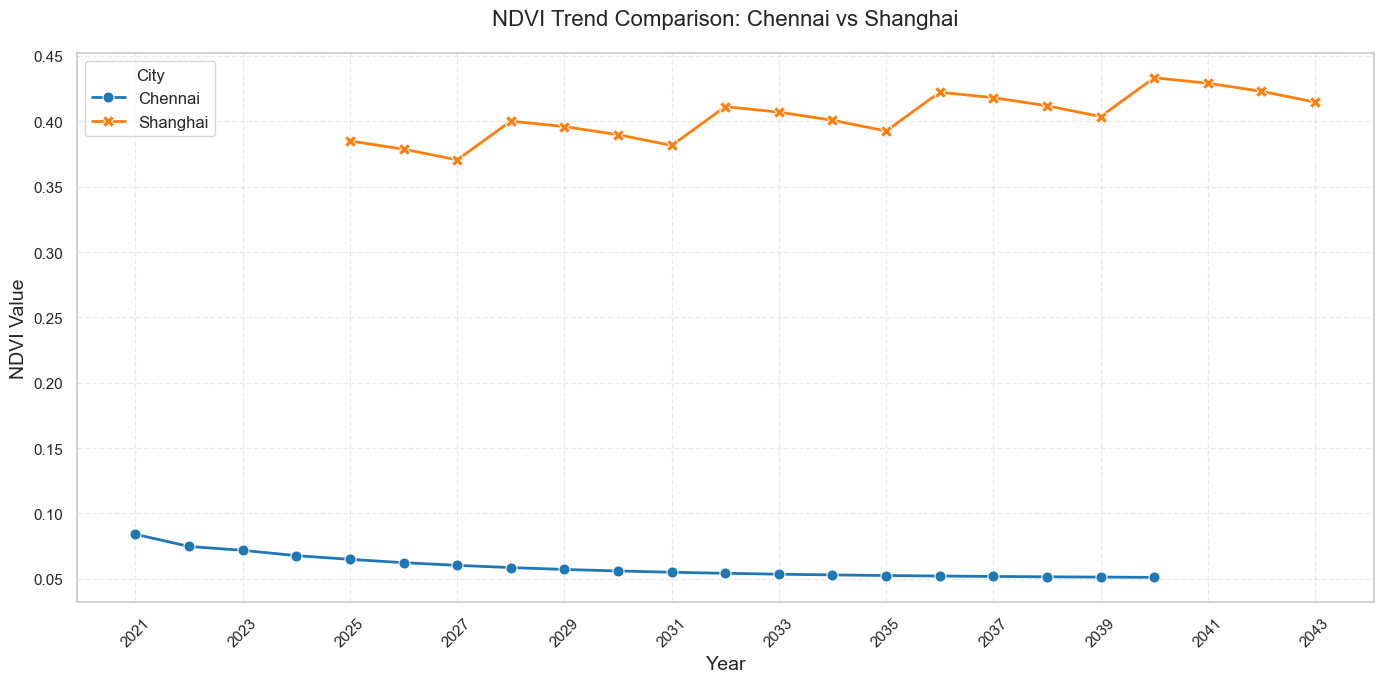

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chennai NDVI Data (2021-2040)
chennai = {
    'Year': list(range(2021, 2041)),
    'NDVI': [0.084018, 0.074696, 0.071754, 0.067674, 0.064847,
             0.062309, 0.060267, 0.05855, 0.057132, 0.055952,
             0.054974, 0.054161, 0.053487, 0.052927, 0.052462,
             0.052077, 0.051756, 0.05149, 0.051269, 0.051086],
    'City': 'Chennai'
}

# Shanghai NDVI Data (2025-2043) 
shanghai = {
    'Year': list(range(2025, 2044)),
    'NDVI': [0.384929, 0.378718, 0.370486, 0.40016, 0.395985,
             0.389774, 0.381542, 0.411216, 0.407041, 0.40083,
             0.392598, 0.422273, 0.418097, 0.411886, 0.403655,
             0.433329, 0.429154, 0.422943, 0.414711],
    'City': 'Shanghai'
}

# Combine data
df = pd.DataFrame([chennai, shanghai]).explode(['Year', 'NDVI'])
df['Year'] = df['Year'].astype(int)
df['NDVI'] = df['NDVI'].astype(float)

# Plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Year', y='NDVI', hue='City', 
             style='City', markers=True, dashes=False,
             palette={'Chennai':'#1f77b4', 'Shanghai':'#ff7f0e'},
             linewidth=2, markersize=8)

plt.title('NDVI Trend Comparison: Chennai vs Shanghai', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('NDVI Value', fontsize=14)
plt.xticks(range(2021, 2044, 2), rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='City', fontsize=12)
plt.tight_layout()
plt.show()

<Figure size 1600x700 with 0 Axes>

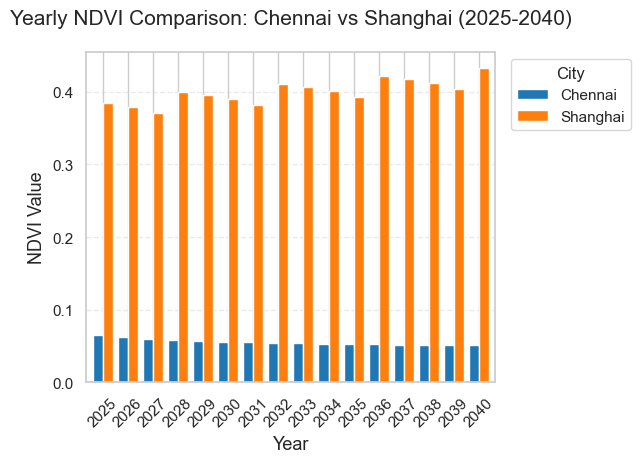

In [18]:
# Filter overlapping years (2025-2040)
df_comparison = df[df['Year'].between(2025, 2040)].pivot(index='Year', columns='City', values='NDVI')

plt.figure(figsize=(16, 7))
df_comparison.plot(kind='bar', width=0.8, color=['#1f77b4', '#ff7f0e'], edgecolor='white')
plt.title('Yearly NDVI Comparison: Chennai vs Shanghai (2025-2040)', fontsize=15, pad=20)
plt.xlabel('Year', fontsize=13)
plt.ylabel('NDVI Value', fontsize=13)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='City', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

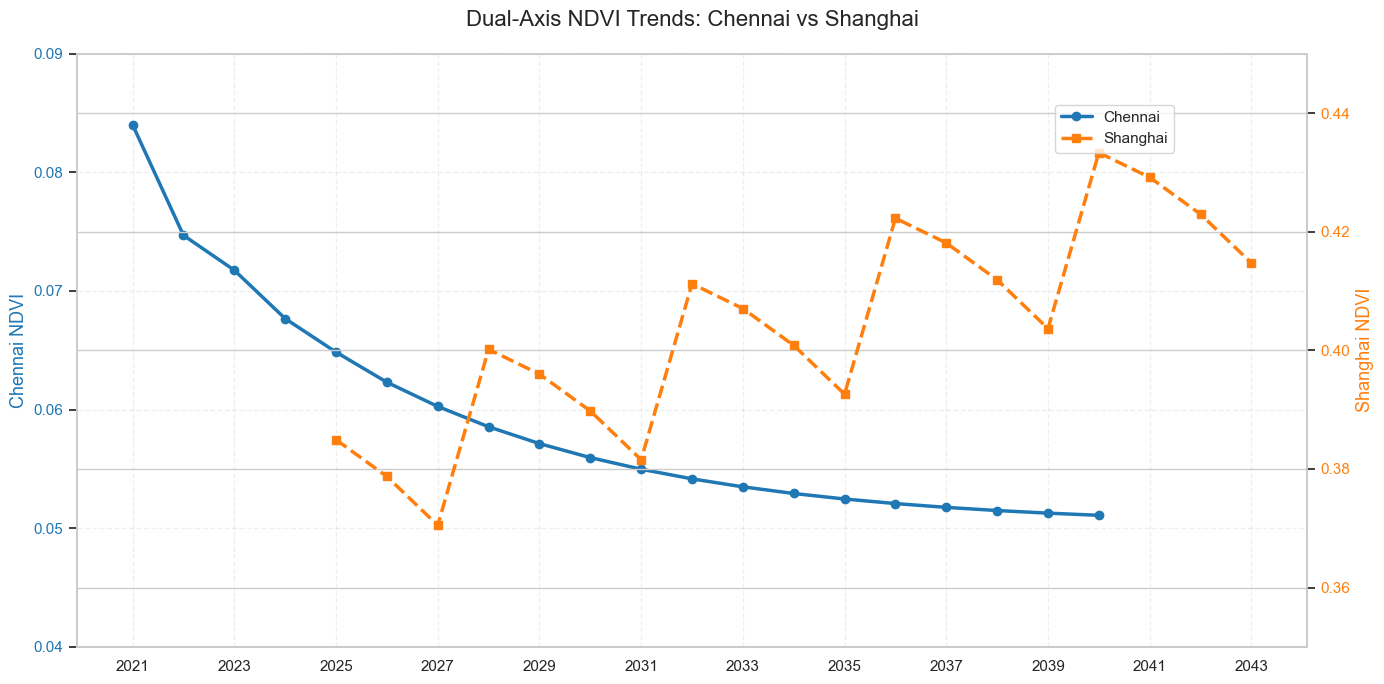

In [19]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Chennai (Left Axis)
ax1.plot(df[df['City']=='Chennai']['Year'], df[df['City']=='Chennai']['NDVI'], 
         color='#1f77b4', linewidth=2.5, marker='o', label='Chennai')
ax1.set_ylabel('Chennai NDVI', color='#1f77b4', fontsize=13)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_ylim(0.04, 0.09)  # Focused range for Chennai

# Shanghai (Right Axis)
ax2 = ax1.twinx()
ax2.plot(df[df['City']=='Shanghai']['Year'], df[df['City']=='Shanghai']['NDVI'], 
         color='#ff7f0e', linewidth=2.5, linestyle='--', marker='s', label='Shanghai')
ax2.set_ylabel('Shanghai NDVI', color='#ff7f0e', fontsize=13)
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax2.set_ylim(0.35, 0.45)  # Focused range for Shanghai

plt.title('Dual-Axis NDVI Trends: Chennai vs Shanghai', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=13)
plt.xticks(range(2021, 2044, 2), rotation=45)
ax1.grid(True, linestyle='--', alpha=0.3)
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.85))
plt.tight_layout()
plt.show()

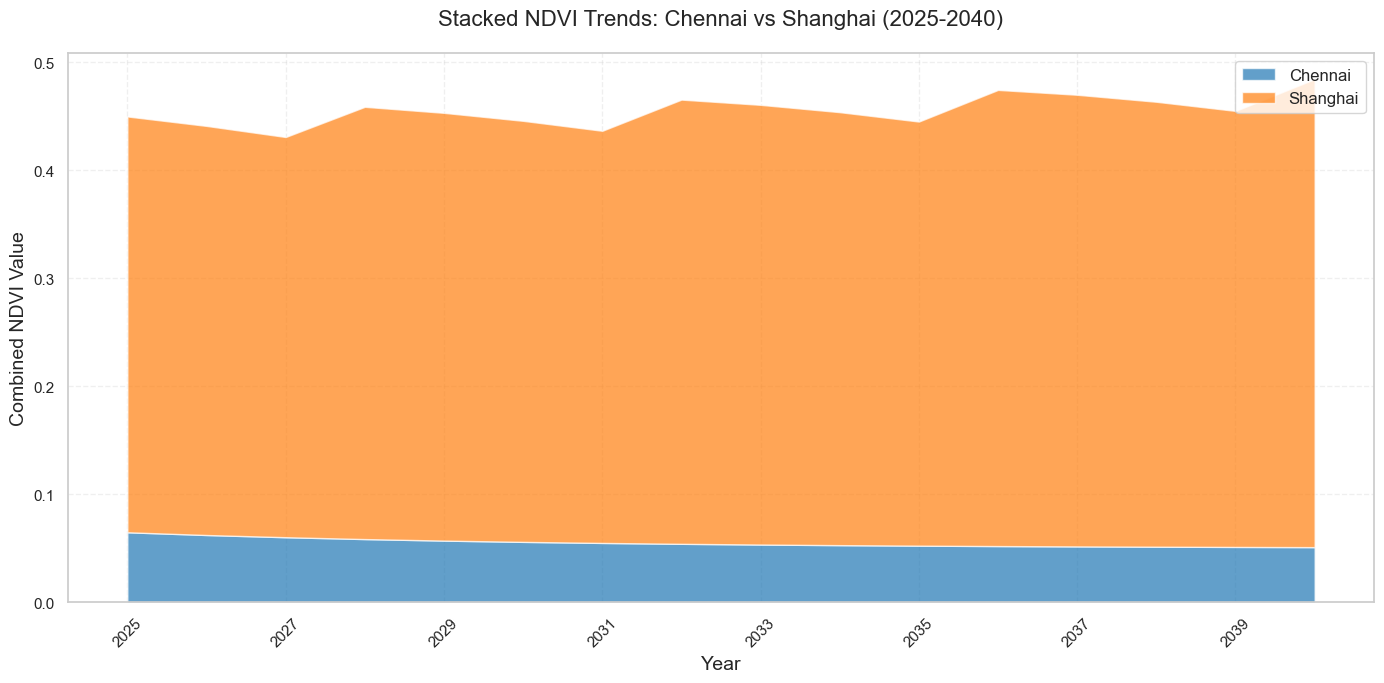

In [20]:
# Prepare data for overlapping years (2025-2040)
df_pivot = df[df['Year'].between(2025, 2040)].pivot(index='Year', columns='City', values='NDVI')

plt.figure(figsize=(14, 7))
plt.stackplot(df_pivot.index, 
              df_pivot['Chennai'], 
              df_pivot['Shanghai'],
              colors=['#1f77b4', '#ff7f0e'],
              alpha=0.7,
              labels=['Chennai', 'Shanghai'])

plt.title('Stacked NDVI Trends: Chennai vs Shanghai (2025-2040)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Combined NDVI Value', fontsize=14)
plt.xticks(range(2025, 2041, 2), rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()